<h1>
Airbnb Price Prediction Project
</h1>

<h3>
1) Problem Statement
</h3>
    <p>
    -The goal of this project is to predict Airbnb listing prices using listing characteristics such as location, room type, review scores, host information, and availability. This notebook demostrates data cleaning, exploratory analysis, feature engineering, model building, hyperparameter tuning, and interpretation.
    </p>

In [29]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans


pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

<h3>
2) Data Loading
</h3>
<p>
We load the Airbnb listings dataset and inspect its structure.
</p>

In [30]:
# =========================================
# 2. LOAD AND COMBINE MULTIPLE CITY DATASETS
# =========================================
CZK_TO_USD = 0.0485

def clean_price_column(series):
    cleaned = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("Kč", "", regex=False)
        .str.replace("CZK", "", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")

# Columbus
columbus = pd.read_csv("listings.csv/listings - Columbus, Ohio.csv")
columbus["city"] = "Columbus"
columbus["price"] = clean_price_column(columbus["price"])

# Nashville
nashville = pd.read_csv("listings.csv/listings - Nashville, Tennessee.csv")
nashville["city"] = "Nashville"
nashville["price"] = clean_price_column(nashville["price"])

# New York
new_york = pd.read_csv("listings.csv/listings - New York, New York.csv")
new_york["city"] = "New York"
new_york["price"] = clean_price_column(new_york["price"])

# Prague
prague = pd.read_csv("listings.csv/listings - Prague, Czech Republic.csv")
prague["city"] = "Prague"
prague["price"] = clean_price_column(prague["price"])
prague["price"] = prague["price"] * CZK_TO_USD

# Combine all datasets
df = pd.concat([columbus, nashville, new_york, prague], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("\nRows by city:")
print(df["city"].value_counts())

print("\nAverage price by city after conversion:")
print(df.groupby("city")["price"].mean().sort_values(ascending=False))

print("\nMissing share by city:")
print(df.groupby("city")["price"].apply(lambda x: x.isna().mean()))

print("\nSample New York raw prices:")
print(pd.read_csv("listings.csv/listings - New York, New York.csv")["price"].head(10).tolist())

print("\nSample New York cleaned prices:")
print(new_york["price"].head(10).tolist())

Combined dataset shape: (59599, 82)

Rows by city:
city
New York     36445
Prague       10834
Nashville     9443
Columbus      2877
Name: count, dtype: int64

Average price by city after conversion:
city
Columbus     327.461024
Nashville    223.399608
Prague       194.493967
New York            NaN
Name: price, dtype: float64

Missing share by city:
city
Columbus     0.063608
Nashville    0.297469
New York     1.000000
Prague       0.123315
Name: price, dtype: float64

Sample New York raw prices:
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Sample New York cleaned prices:
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


<h3>
3) Data Exploration
</h3>
<p>
We examine the distributions of price and important features, check missing values, and identify useful columns.
</p>

Dataset shape: (59599, 82)

City counts before cleaning:
city
New York     36445
Prague       10834
Nashville     9443
Columbus      2877
Name: count, dtype: int64

Top missing values:
calendar_updated                59599
neighbourhood_group_cleansed    59599
neighborhood_overview           58087
host_about                      57724
host_location                   57324
review_scores_rating            57041
review_scores_communication     57041
review_scores_checkin           57041
review_scores_value             57041
review_scores_location          57041
first_review                    57041
review_scores_accuracy          57041
review_scores_cleanliness       57041
host_neighbourhood              56929
bathrooms                       56906
beds                            56905
estimated_revenue_l365d         56905
host_response_time              56896
host_response_rate              56896
host_is_superhost               56883
dtype: int64

Price summary statistics:
count    18826.

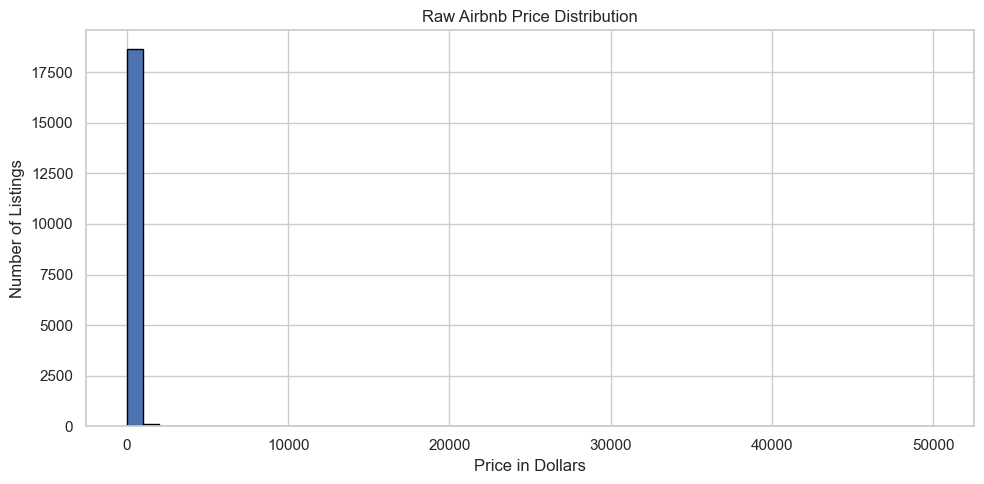

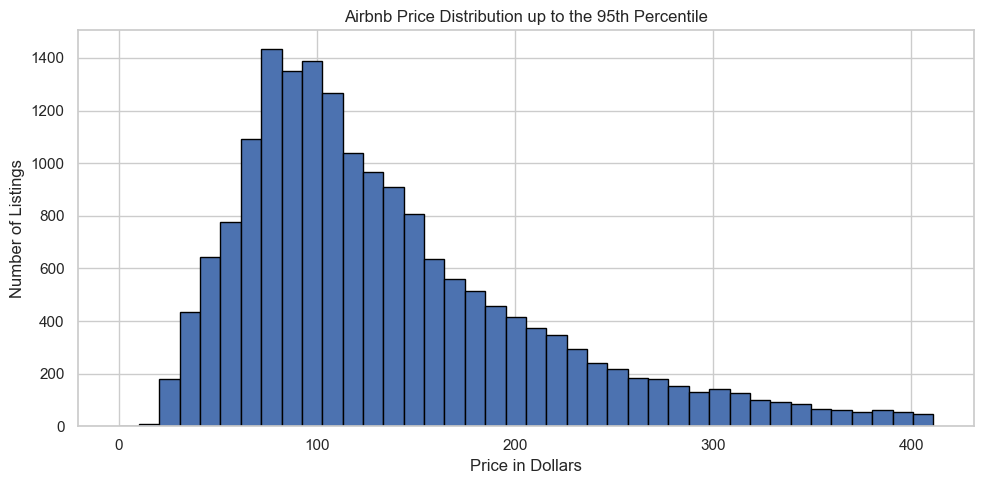

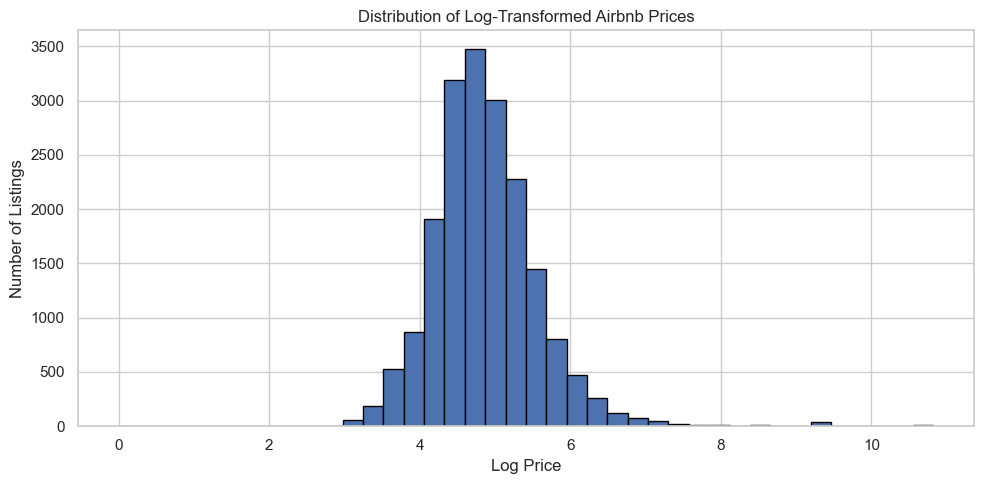

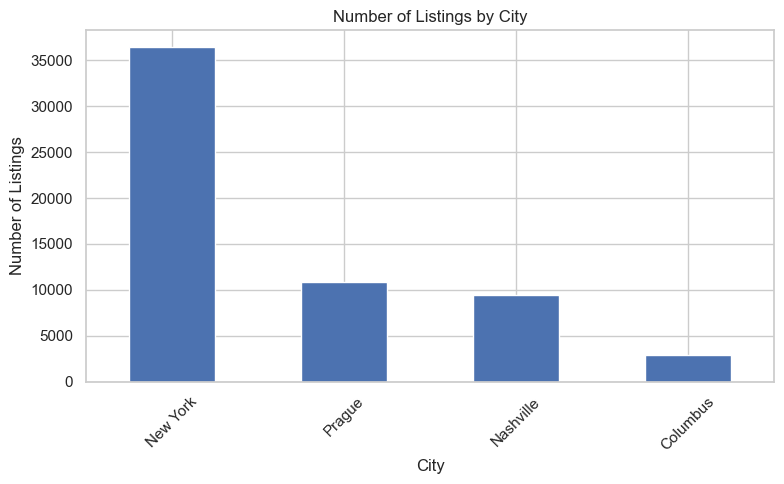

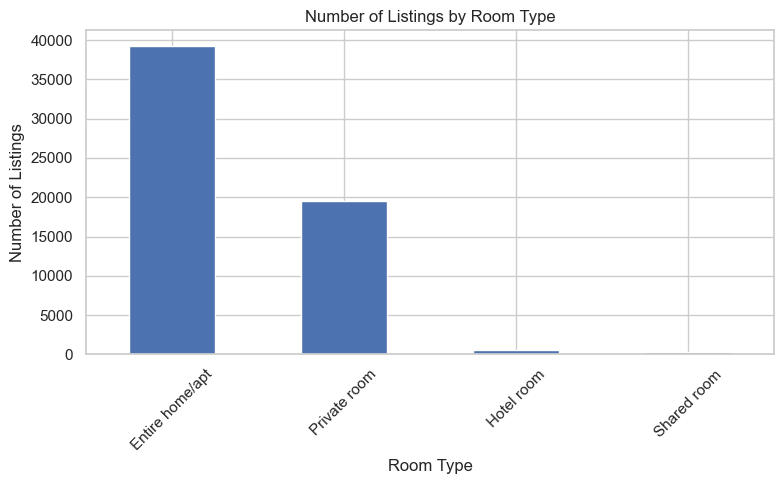

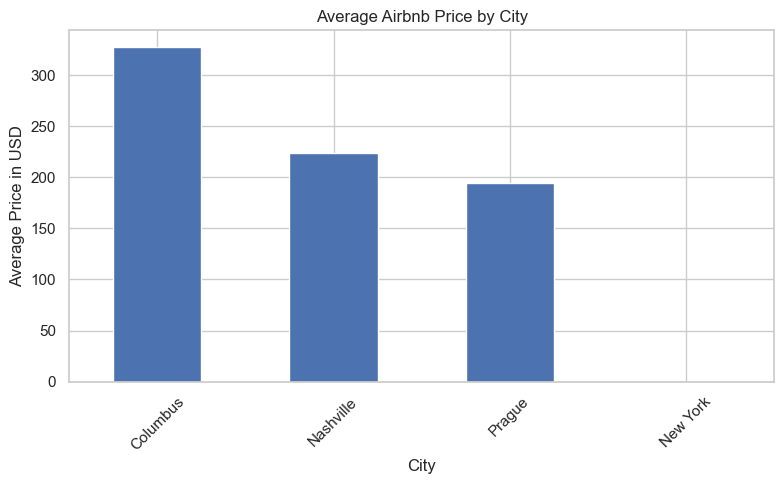

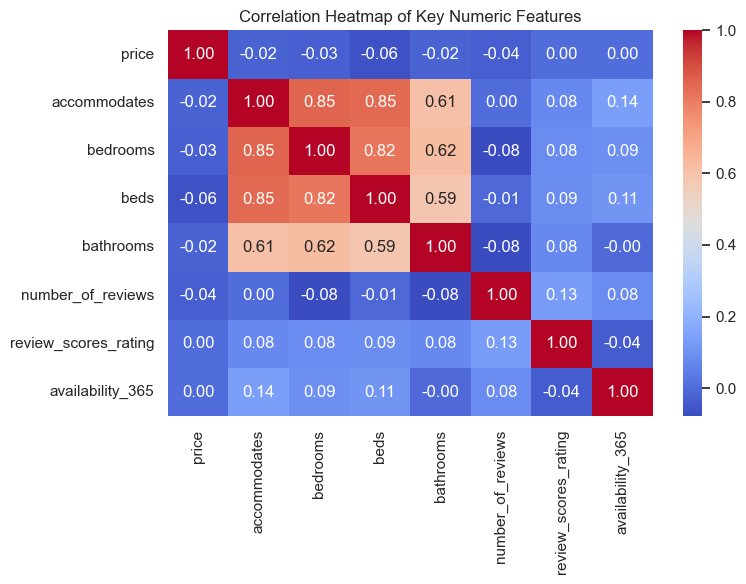

In [17]:
# =========================================
# 3. DATA EXPLORATION
# =========================================

print("Dataset shape:", df.shape)

print("\nCity counts before cleaning:")
print(df["city"].value_counts())

print("\nTop missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nPrice summary statistics:")
print(df["price"].describe())

print("\nAverage price by city:")
print(df.groupby("city")["price"].mean().sort_values(ascending=False))

print("\nTop 10 most expensive listings:")
print(df["price"].sort_values(ascending=False).head(10))

# Raw histogram
plt.figure(figsize=(10, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.xlabel("Price in Dollars")
plt.ylabel("Number of Listings")
plt.title("Raw Airbnb Price Distribution")
plt.tight_layout()
plt.show()

# Histogram up to global 95th percentile for readability only
price_95 = df["price"].quantile(0.95)

plt.figure(figsize=(10, 5))
plt.hist(df.loc[df["price"] <= price_95, "price"].dropna(), bins=40, edgecolor="black")
plt.xlabel("Price in Dollars")
plt.ylabel("Number of Listings")
plt.title("Airbnb Price Distribution up to the 95th Percentile")
plt.tight_layout()
plt.show()

# Log-price exploration
log_price = np.log1p(df["price"])

plt.figure(figsize=(10, 5))
plt.hist(log_price.dropna(), bins=40, edgecolor="black")
plt.xlabel("Log Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Log-Transformed Airbnb Prices")
plt.tight_layout()
plt.show()

# Listings by city
plt.figure(figsize=(8, 5))
df["city"].value_counts().plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Number of Listings")
plt.title("Number of Listings by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Listings by room type
if "room_type" in df.columns:
    plt.figure(figsize=(8, 5))
    df["room_type"].value_counts().plot(kind="bar")
    plt.xlabel("Room Type")
    plt.ylabel("Number of Listings")
    plt.title("Number of Listings by Room Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Average price by city
city_avg_price = df.groupby("city")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
city_avg_price.plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Average Price in USD")
plt.title("Average Airbnb Price by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap
candidate_cols = [
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "review_scores_rating",
    "availability_365"
]
existing_cols = [col for col in candidate_cols if col in df.columns]

if len(existing_cols) > 1:
    plt.figure(figsize=(8, 6))
    corr = df[existing_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap of Key Numeric Features")
    plt.tight_layout()
    plt.show()

<h3>
4) Data Cleaning
</h3>
<p>
We clean the target variable, handle missing values, convert categorical variables, and process datetime columns.
</p>

New dataset shape after 95 percent cutoff: (17882, 82)


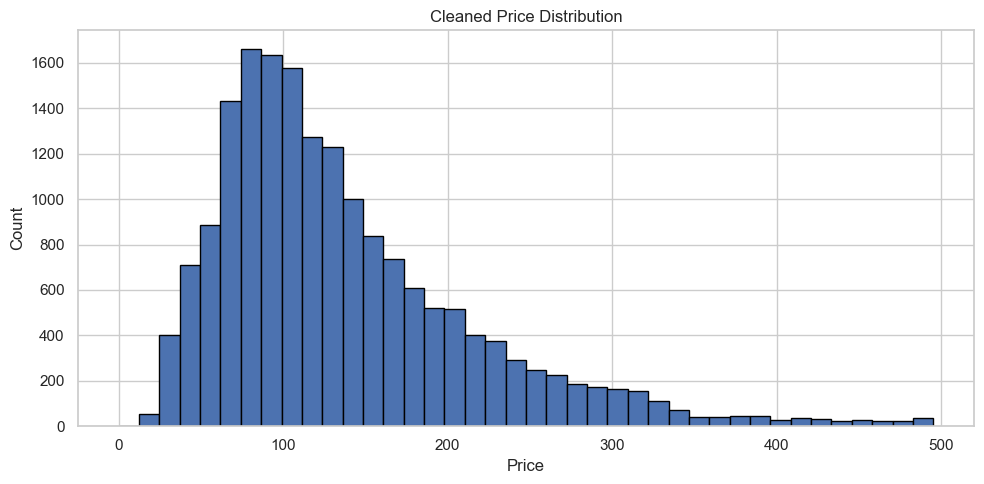

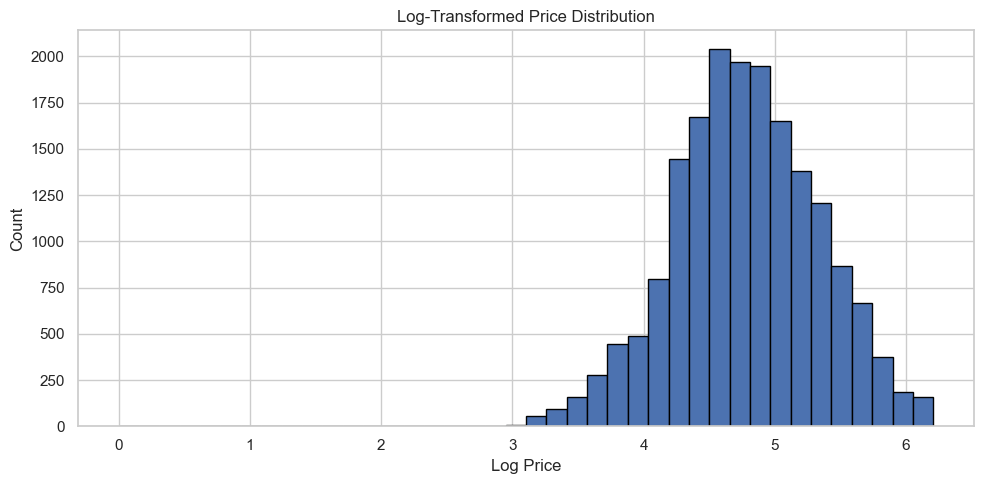

In [18]:
# =========================================
# 4. CLEAN TARGET VARIABLE
# =========================================

df = df.dropna(subset=["price"]).copy()

# Remove extreme outliers
df = df[df["price"] < df.groupby("city")["price"].transform(lambda x: x.quantile(0.95))]

print("New dataset shape after 95 percent cutoff:", df.shape)

# Log-transform target
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(10, 5))
plt.hist(df["price"].dropna(), bins=40, edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Cleaned Price Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["log_price"].dropna(), bins=40, edgecolor="black")
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.title("Log-Transformed Price Distribution")
plt.tight_layout()
plt.show()

<h3>
5) Feature Engineering
</h3>
<p>
We create additional predictors such as host tenure, days since review, amenities count, and location-based features.
</p>

In [19]:
# =========================================
# 5. DATETIME FEATURES
# =========================================
date_cols = ["host_since", "first_review", "last_review", "last_scraped", "calendar_last_scraped"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

reference_date = df["last_scraped"].max() if "last_scraped" in df.columns else pd.Timestamp.today()

if "host_since" in df.columns:
    df["host_tenure_days"] = (reference_date - df["host_since"]).dt.days

if "first_review" in df.columns:
    df["days_since_first_review"] = (reference_date - df["first_review"]).dt.days

if "last_review" in df.columns:
    df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days

<h3>
6) Train/Validation/Test Split
</h3>
<p>
The data is split into train, validation, and test sets for proper model development and evaluation.
</p>

In [20]:
# =========================================
# 6. FEATURE ENGINEERING
# =========================================

# Convert percentage columns
for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("%", "", regex=False)
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert boolean-style columns
bool_map = {"t": 1, "f": 0}
for col in [
    "instant_bookable",
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "has_availability"
]:
    if col in df.columns:
        df[col] = df[col].map(bool_map)

# Extract numeric bathrooms from text
if "bathrooms_text" in df.columns:
    df["bathrooms_text_num"] = (
        df["bathrooms_text"]
        .astype(str)
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

# Count amenities
if "amenities" in df.columns:
    def count_amenities(x):
        try:
            return len(ast.literal_eval(x))
        except:
            return np.nan

    df["amenities_count"] = df["amenities"].apply(count_amenities)

# Distance from overall dataset center
if "latitude" in df.columns and "longitude" in df.columns:
    df["distance_from_center"] = (
        (df["latitude"] - df["latitude"].mean()) ** 2 +
        (df["longitude"] - df["longitude"].mean()) ** 2
    )

# Stronger engineered features

if "bedrooms" in df.columns and "accommodates" in df.columns:
    df["bedroom_density"] = df["bedrooms"] / (df["accommodates"] + 1)

if "beds" in df.columns and "accommodates" in df.columns:
    df["bed_density"] = df["beds"] / (df["accommodates"] + 1)

if "availability_365" in df.columns:
    df["availability_ratio"] = df["availability_365"] / 365

if "number_of_reviews" in df.columns and "host_listings_count" in df.columns:
    df["reviews_per_listing"] = df["number_of_reviews"] / (df["host_listings_count"] + 1)

if "number_of_reviews" in df.columns and "host_tenure_days" in df.columns:
    df["reviews_per_day"] = df["number_of_reviews"] / (df["host_tenure_days"] + 1)

if "accommodates" in df.columns and "bedrooms" in df.columns:
    df["accommodates_x_bedrooms"] = df["accommodates"] * df["bedrooms"]

if "latitude" in df.columns and "longitude" in df.columns:
    df["location_cluster"] = -1
    cluster_offset = 0

    for city in df["city"].unique():
        subset = df[df["city"] == city]
        
        kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
        labels = kmeans.fit_predict(subset[["latitude", "longitude"]])
        
        df.loc[subset.index, "location_cluster"] = labels + cluster_offset
        cluster_offset += 10

<h3>
7) Models
</h3>
<p>
We compare multiple models including a baseline, Random Forest, and Gradient Boosting.
</p>

In [21]:
# =========================================
# 7. SELECT FEATURES
# =========================================
feature_cols = [
    "city",
    "accommodates",
    "bathrooms",
    "bathrooms_text_num",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "availability_eoy",
    "estimated_occupancy_l365d",
    "host_response_rate",
    "host_acceptance_rate",
    "latitude",
    "longitude",
    "distance_from_center",
    "host_tenure_days",
    "days_since_first_review",
    "days_since_last_review",
    "amenities_count",
    "instant_bookable",
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "has_availability",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "host_response_time",
    "source",
    "bedroom_density",
    "bed_density",
    "availability_ratio",
    "reviews_per_listing",
    "reviews_per_day",
    "accommodates_x_bedrooms",
    "location_cluster"
]

feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols].copy()
y = df["log_price"]

print("Number of selected features:", len(feature_cols))
print(feature_cols)

Number of selected features: 57
['city', 'accommodates', 'bathrooms', 'bathrooms_text_num', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'reviews_per_month', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'estimated_occupancy_l365d', 'host_response_rate', 'host_acceptance_rate', 'latitude', 'longitude', 'distance_from_center', 'host_tenure_days', 'days_since_first_review', 'days_since_last_review', 'amenities_count', 'instant_bookable', 'host_is_super

<h3>
8) Hyperparameter Tuning
</h3>
<p>
We tune the strongest models to improve predictive performance.
</p>

In [22]:
# =========================================
# 8. TRAIN / DEV / TEST SPLIT
# =========================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=X["city"] if "city" in X.columns else None
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=X_train_full["city"] if "city" in X_train_full.columns else None
)

print("Train shape:", X_train.shape)
print("Dev shape:", X_dev.shape)
print("Test shape:", X_test.shape)

if "city" in X.columns:
    print("\nCity distribution in Train:")
    print(X_train["city"].value_counts(normalize=True))
    print("\nCity distribution in Dev:")
    print(X_dev["city"].value_counts(normalize=True))
    print("\nCity distribution in Test:")
    print(X_test["city"].value_counts(normalize=True))

Train shape: (10728, 57)
Dev shape: (3577, 57)
Test shape: (3577, 57)

City distribution in Train:
city
Prague       0.504567
Nashville    0.352442
Columbus     0.142990
Name: proportion, dtype: float64

City distribution in Dev:
city
Prague       0.504613
Nashville    0.352250
Columbus     0.143137
Name: proportion, dtype: float64

City distribution in Test:
city
Prague       0.504613
Nashville    0.352250
Columbus     0.143137
Name: proportion, dtype: float64


<h3>
9) Model Evaluation
</h3>
<p>
We evaluate models using MAE and R², and convert predictions back into dollar scale for interpretability.
</p>

In [23]:
# =========================================
# 9. PREPROCESSING PIPELINE
# =========================================
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in X.columns if col not in numeric_cols]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

<h3>
10) Model Interpretation
</h3>
<p>
We inspect feature importance and permutation importance, and optionally SHAP values for the final model.
</p>

In [24]:
# =========================================
# 10. BASELINE AND MULTIPLE MODELS
# =========================================

# Simple baseline
baseline_pred_log = np.full(shape=len(y_dev), fill_value=y_train.mean())
baseline_mae_dollars = mean_absolute_error(np.expm1(y_dev), np.expm1(baseline_pred_log))
print("Baseline MAE in dollars:", baseline_mae_dollars)

models = {
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=300,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=400,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8
    )
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_dev)

    mae_log = mean_absolute_error(y_dev, preds)
    mae_dollars = mean_absolute_error(np.expm1(y_dev), np.expm1(preds))
    r2 = r2_score(y_dev, preds)

    results.append({
        "Model": name,
        "MAE_log": mae_log,
        "MAE_dollars": mae_dollars,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("MAE_dollars")
print(results_df)

Baseline MAE in dollars: 57.38764981239211
              Model   MAE_log  MAE_dollars        R2
1      RandomForest  0.267487    37.766159  0.597051
2  GradientBoosting  0.273482    38.438479  0.591764
0             Ridge  0.348629    47.380450  0.373849


<h3>
11) Conclusion
</h3>
<p>
We summarize the most important predictors of Airbnb prices and discuss possible future improvements.
</p>

In [25]:
# =========================================
# 11. HYPERPARAMETER TUNING
# =========================================
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [15, 20, 25, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=12,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_full, y_train_full)

print("Best params:")
print(search.best_params_)

best_model = search.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 25}


<h3>
Final Test Evaluation
</h3>

In [26]:
# =========================================
# 12. FINAL TEST EVALUATION
# =========================================
test_preds = best_model.predict(X_test)

test_mae_log = mean_absolute_error(y_test, test_preds)
test_mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(test_preds))
test_r2 = r2_score(y_test, test_preds)

print("\nFinal Test Results")
print("MAE (log):", test_mae_log)
print("MAE (dollars):", test_mae_dollars)
print("R2:", test_r2)


Final Test Results
MAE (log): 0.2586755096982459
MAE (dollars): 36.74902129261123
R2: 0.6165430554298093


<h3>
Prediction Plot
</h3>

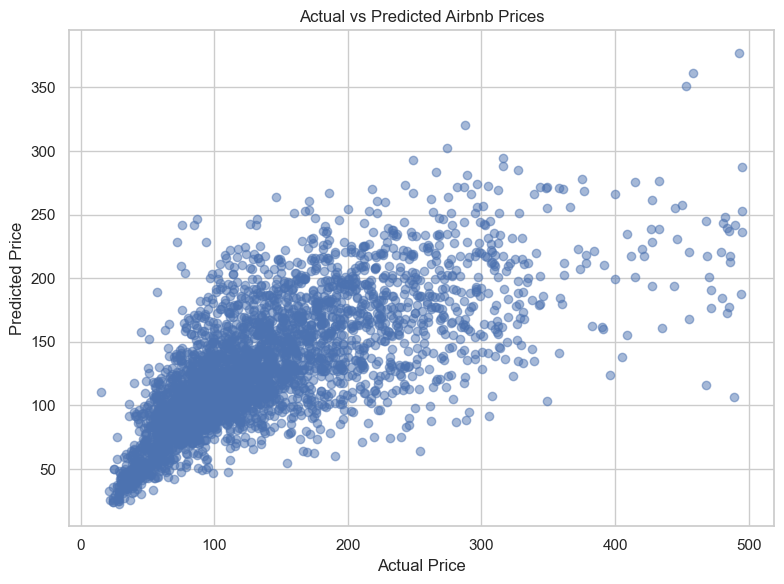

In [27]:
# =========================================
# 13. ACTUAL VS PREDICTED PLOT
# =========================================
actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(test_preds)

plt.figure(figsize=(8, 6))
plt.scatter(actual_prices, predicted_prices, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")
plt.tight_layout()
plt.show()

<h3>
Permutation Importance
</h3>

In [28]:
# =========================================
# 14. PERMUTATION IMPORTANCE
# =========================================
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Permutation Importances")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
# =========================================
# XGBOOST MODEL
# =========================================

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Base XGBoost model
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit on training set
xgb_pipe.fit(X_train, y_train)

# Predict on dev set
xgb_dev_preds = xgb_pipe.predict(X_dev)

# Evaluate on dev set
xgb_dev_mae_log = mean_absolute_error(y_dev, xgb_dev_preds)
xgb_dev_mae_dollars = mean_absolute_error(np.expm1(y_dev), np.expm1(xgb_dev_preds))
xgb_dev_r2 = r2_score(y_dev, xgb_dev_preds)

print("XGBoost Dev Results")
print("MAE (log):", xgb_dev_mae_log)
print("MAE (dollars):", xgb_dev_mae_dollars)
print("R2:", xgb_dev_r2)

XGBoost Dev Results
MAE (log): 0.2553816052211439
MAE (dollars): 35.1371101244728
R2: 0.5986071341804707


In [ ]:
# =========================================
# XGBOOST HYPERPARAMETER TUNING
# =========================================

xgb_tune_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_dist = {
    "model__n_estimators": [300, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__reg_lambda": [1.0, 1.5, 2.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_tune_pipe,
    param_distributions=xgb_param_dist,
    n_iter=15,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_full, y_train_full)

print("Best XGBoost params:")
print(xgb_search.best_params_)

best_xgb_model = xgb_search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGBoost params:
{'model__subsample': 0.7, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0, 'model__n_estimators': 700, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}


In [ ]:
# =========================================
# FINAL TEST EVALUATION FOR XGBOOST
# =========================================

xgb_test_preds = best_xgb_model.predict(X_test)

xgb_test_mae_log = mean_absolute_error(y_test, xgb_test_preds)
xgb_test_mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(xgb_test_preds))
xgb_test_r2 = r2_score(y_test, xgb_test_preds)

print("\nFinal XGBoost Test Results")
print("MAE (log):", xgb_test_mae_log)
print("MAE (dollars):", xgb_test_mae_dollars)
print("R2:", xgb_test_r2)


Final XGBoost Test Results
MAE (log): 0.24115843217459199
MAE (dollars): 34.516066406471886
R2: 0.63865441764579


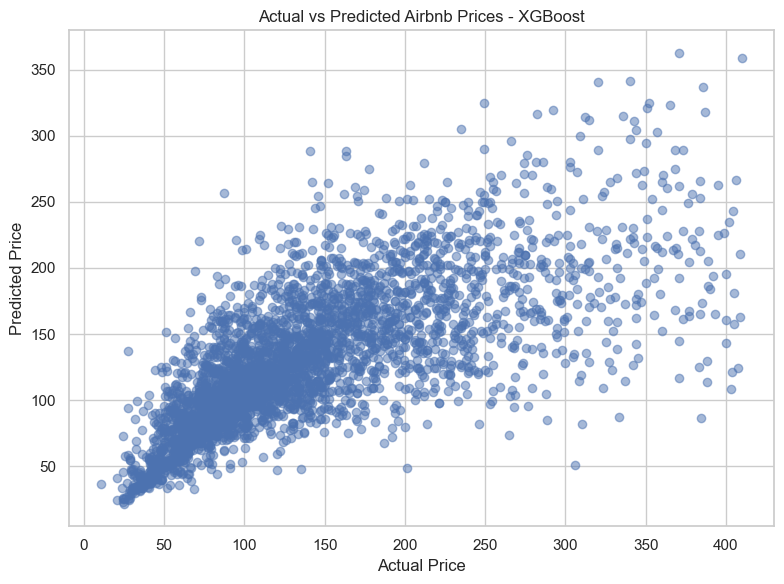

In [ ]:
# =========================================
# ACTUAL VS PREDICTED FOR XGBOOST
# =========================================

actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(xgb_test_preds)

plt.figure(figsize=(8, 6))
plt.scatter(actual_prices, predicted_prices, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices - XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
mean_price = np.expm1(y_test).mean()
relative_error = 332 / mean_price

print("Mean price:", mean_price)
print("Relative error:", relative_error)

Mean price: 137.55691401006712
Relative error: 2.413546439226621


In [ ]:
# =========================================
# ENSEMBLE MODEL (BEST FINAL STEP)
# =========================================

rf_preds = best_model.predict(X_test)
xgb_preds = best_xgb_model.predict(X_test)

# Average predictions
ensemble_preds = (rf_preds * 0.5 + xgb_preds * 0.5)

ensemble_mae = mean_absolute_error(
    np.expm1(y_test),
    np.expm1(ensemble_preds)
)

ensemble_r2 = r2_score(y_test, ensemble_preds)

print("\nEnsemble Results")
print("MAE (dollars):", ensemble_mae)
print("R2:", ensemble_r2)


Ensemble Results
MAE (dollars): 34.15974758336093
R2: 0.6445639597471748
